In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
import numpy as np
import os # Importamos 'os' para crear las carpetas
from sqlalchemy import create_engine
from urllib.parse import quote_plus 

# Importaciones para la Red Neuronal
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

# Configura matplotlib para que los gráficos se vean bien
%matplotlib inline

In [2]:
# 1. Credenciales de la Base de Datos
DB_USER = "myvolt_admin" 
DB_PASS = "M%R^N!J%IDKS$8@zya4v"
DB_HOST = "myvolt-db.postgres.database.azure.com"
DB_PORT = "5432"
DB_NAME = "postgres" 

# 2. Codificar la contraseña
DB_PASS_ENCODED = quote_plus(DB_PASS)

# 3. Crear la cadena de conexión
try:
    connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require"
    engine = create_engine(connection_string)
    
    # 4. Prueba de conexión
    with engine.connect() as conn:
        print("¡Conexión a Azure PostgreSQL exitosa!")
        
except Exception as e:
    print(f"Error al conectar a Azure: {e}")

¡Conexión a Azure PostgreSQL exitosa!


In [3]:
# Consulta SQL para traer los datos más recientes (los del Foco LED)
query = """
SELECT time, power_w
FROM consumption_data
WHERE id_device = (
    SELECT id_device 
    FROM devices 
    WHERE mac_address = 'B0:A7:32:34:54:9C'
)
ORDER BY time DESC
LIMIT 5000; 
"""

# Usamos Pandas para ejecutar la consulta y cargar los datos
df = pd.read_sql_query(query, con=engine)

print(f"Se cargaron {len(df)} registros (los más recientes) desde la base de datos.")
df.head()

Se cargaron 5000 registros (los más recientes) desde la base de datos.


,time,power_w
0,2025-11-10 04:04:22.357731+00:00,0.0
1,2025-11-10 04:04:22.156266+00:00,0.0
2,2025-11-10 04:04:21.953671+00:00,0.0
3,2025-11-10 04:04:21.751720+00:00,0.0
4,2025-11-10 04:04:21.551608+00:00,0.0


In [4]:
# 1. Preparar los datos (solo la columna 'power_w')
datos_para_modelo = df[['power_w']]

# 2. Crear el Escalador
scaler = MinMaxScaler()

# 3. Entrenar el escalador y transformar los datos
datos_escalados = scaler.fit_transform(datos_para_modelo)

print("Datos escalados (convertidos de 0 a 1):")
print(datos_escalados[:5])

Datos escalados (convertidos de 0 a 1):
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [5]:
# 1. Definir la forma de nuestra entrada (1 solo número: power_w)
input_layer = Input(shape=(1,))

# 2. "Encoder" (Comprime la información)
encoder = Dense(8, activation='relu')(input_layer)
encoder = Dense(4, activation='relu')(encoder) # Cuello de botella

# 3. "Decoder" (Intenta reconstruir la información)
decoder = Dense(8, activation='relu')(encoder)
decoder = Dense(1, activation='sigmoid')(decoder) # Salida entre 0 y 1

# 4. Crear el modelo Autoencoder
autoencoder = Model(inputs=input_layer, outputs=decoder)

# 5. Compilar el modelo (con la métrica 'mae')
autoencoder.compile(optimizer='adam', loss='mae', metrics=['mae'])

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Entrenamos el modelo
historial = autoencoder.fit(
    datos_escalados, # X (Entrada)
    datos_escalados, # y (Lo que debe predecir)
    epochs=50,       # 50 pasadas por los datos
    batch_size=32,
    shuffle=True,
    validation_split=0.1 # Usa el 10% de los datos para autoevaluarse
)

print("¡Autoencoder de Foco LED entrenado!")

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3469 - mae: 0.3469 - val_loss: 0.2895 - val_mae: 0.2895
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2624 - mae: 0.2624 - val_loss: 0.1855 - val_mae: 0.1855
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1365 - mae: 0.1365 - val_loss: 0.0725 - val_mae: 0.0725
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0617 - mae: 0.0617 - val_loss: 0.0454 - val_mae: 0.0454
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0440 - mae: 0.0440 - val_loss: 0.0412 - val_mae: 0.0412
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0397 - mae: 0.0397 - val_loss: 0.0402 - val_mae: 0.0402
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0387 - mae: 0.0387 - val_loss: 0.0407 - val_mae: 0.0407
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0381 - mae: 0.0381 - val_loss: 0.0406 - val_mae: 0.0406
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [7]:
# 1. Obtenemos el último (el final) error de validación (val_loss) del historial
final_error = historial.history['val_loss'][-1]

# 2. Calculamos la "precisión de reconstrucción" como (1 - error)
final_precision_pct = (1 - final_error) * 100

print(f"Resultados del Entrenamiento de la Red Neuronal (Foco LED):")
print(f"Error Final (val_loss): {final_error:.6f} (o {final_error*100:.2f}%)")
print(f"Precisión de Reconstrucción Final: {final_precision_pct:.2f}%")

Resultados del Entrenamiento de la Red Neuronal (Foco LED):
Error Final (val_loss): 0.041065 (o 4.11%)
Precisión de Reconstrucción Final: 95.89%


In [8]:
# 1. Obtenemos las "predicciones" (los datos reconstruidos)
datos_reconstruidos = autoencoder.predict(datos_escalados)

# 2. Calculamos el error (la diferencia) entre el original y la copia
errores = mean_absolute_error(datos_escalados.T, datos_reconstruidos.T, multioutput='raw_values')
df['error_nn'] = errores

# 3. Definimos el umbral: cualquier cosa por encima del 98% de los errores es una anomalía
umbral = np.percentile(df['error_nn'], 98)

print(f"Error de reconstrucción promedio: {np.mean(df['error_nn'])}")
print(f"UMBRAL DE ANOMALÍA (Foco LED) establecido en: {umbral}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Error de reconstrucción promedio: 0.03829909186246495
UMBRAL DE ANOMALÍA (Foco LED) establecido en: 0.13876043756802875


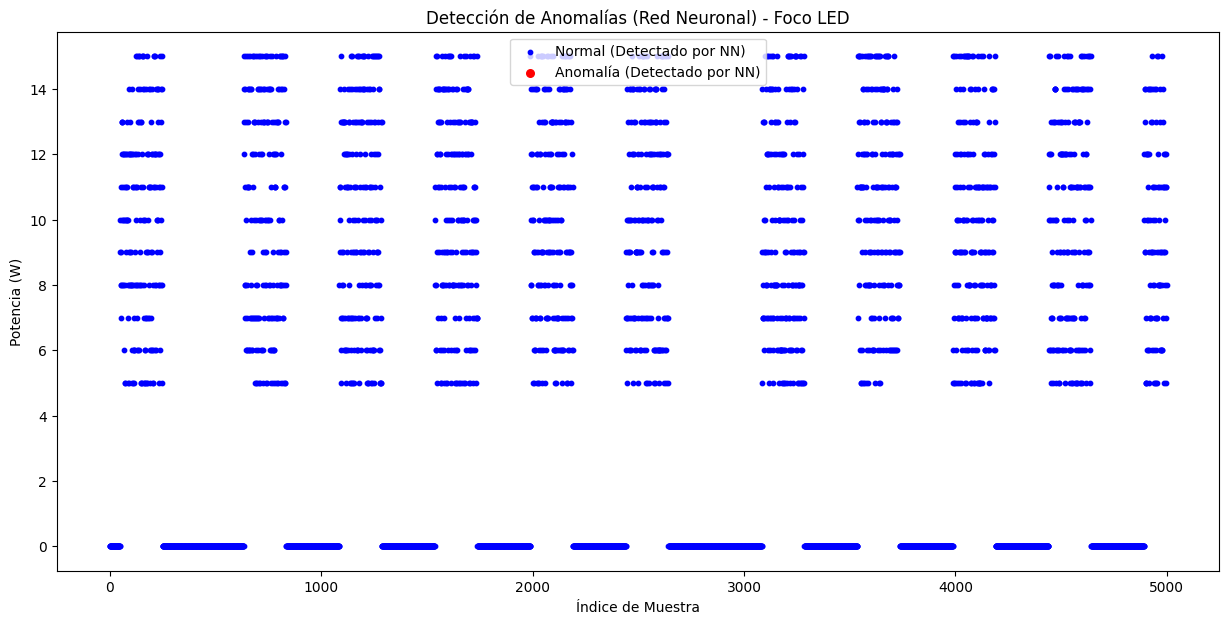

In [9]:
# Identificamos las anomalías (donde el error es MAYOR al umbral)
df['anomalia_nn'] = df['error_nn'] > umbral

# Separamos los datos
df_normal = df[df['anomalia_nn'] == False]
df_anomalo = df[df['anomalia_nn'] == True]

# Creamos el gráfico
plt.figure(figsize=(15, 7))
# Deberías ver dos nubes azules: una en 0W y otra en 5-15W
plt.scatter(df_normal.index, df_normal['power_w'], 
            c='blue', label='Normal (Detectado por NN)', s=10)
plt.scatter(df_anomalo.index, df_anomalo['power_w'], 
            c='red', label='Anomalía (Detectado por NN)', s=30)

plt.title('Detección de Anomalías (Red Neuronal) - Foco LED')
plt.xlabel('Índice de Muestra')
plt.ylabel('Potencia (W)')
plt.legend()
plt.show()

In [10]:
# 1. Definimos las rutas de salida
ruta_modelo_nn = '../neural_network/foco_led_autoencoder_v1.h5'
ruta_scaler_nn = '../scaler/foco_led_scaler_v1.pkl'

# 2. Nos aseguramos de que las carpetas existan
os.makedirs(os.path.dirname(ruta_modelo_nn), exist_ok=True)
os.makedirs(os.path.dirname(ruta_scaler_nn), exist_ok=True)

# 3. Guardar el modelo de Red Neuronal (formato .h5)
autoencoder.save(ruta_modelo_nn)

# 4. Guardar el escalador (el que convierte de 0-15 a 0-1)
joblib.dump(scaler, ruta_scaler_nn)

print(f"¡Modelo de Foco LED guardado en: {ruta_modelo_nn}!")
print(f"¡Escalador de Foco LED guardado en: {ruta_scaler_nn}!")

¡Modelo de Foco LED guardado en: ../neural_network/foco_led_autoencoder_v1.h5!
¡Escalador de Foco LED guardado en: ../scaler/foco_led_scaler_v1.pkl!
